In [74]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu

In [75]:
df = pd.read_csv('Agri_Data_Cleaned.csv')

# 2. Tính toán Yield = Production / Area

In [76]:
df['Yield'] = df['Production'] / df['Area']

# 3. Xử lý lỗi chia cho 0

In [77]:
df['Yield'] = df['Yield'].replace([np.inf, -np.inf], np.nan)

In [78]:
print(df[['Area', 'Production', 'Yield']].head())
print("\nThống kê mô tả của Yield:")
print(df['Yield'].describe())

   Area  Production  Yield
0     1           6    6.0
1     1           1    1.0
2     1          21   21.0
3     1          12   12.0
4     1           1    1.0

Thống kê mô tả của Yield:
count    4178.000000
mean        4.819818
std        17.983998
min         0.013926
25%         1.295835
50%         2.534911
75%         4.725979
max       951.216667
Name: Yield, dtype: float64


Đang phân tích 44 cột dữ liệu số...

--- BẢNG TỔNG HỢP GIÁ TRỊ NGOẠI LAI (TOP CAO NHẤT) ---


,Column,Outliers_Count,Outliers_Percentage (%),Lower_Bound,Upper_Bound
40,Is_Extreme_Heat,1021,24.44,0.00,0.00
41,is_extreme_Heat_Stress_Days,729,17.45,0.00,0.00
0,Area,619,14.82,-1159.62,2215.38
4,Production,605,14.48,-4605.50,8302.50
1,AP Ratio,389,9.31,-3.85,9.87
43,Yield,389,9.31,-3.85,9.87
32,Rootzone_Surface_Diff,253,6.06,-0.02,0.09
31,sm_rootzone,200,4.79,0.13,0.44
33,Moisture_Ratio,137,3.28,0.84,1.55
27,Silt,130,3.11,28.60,51.19


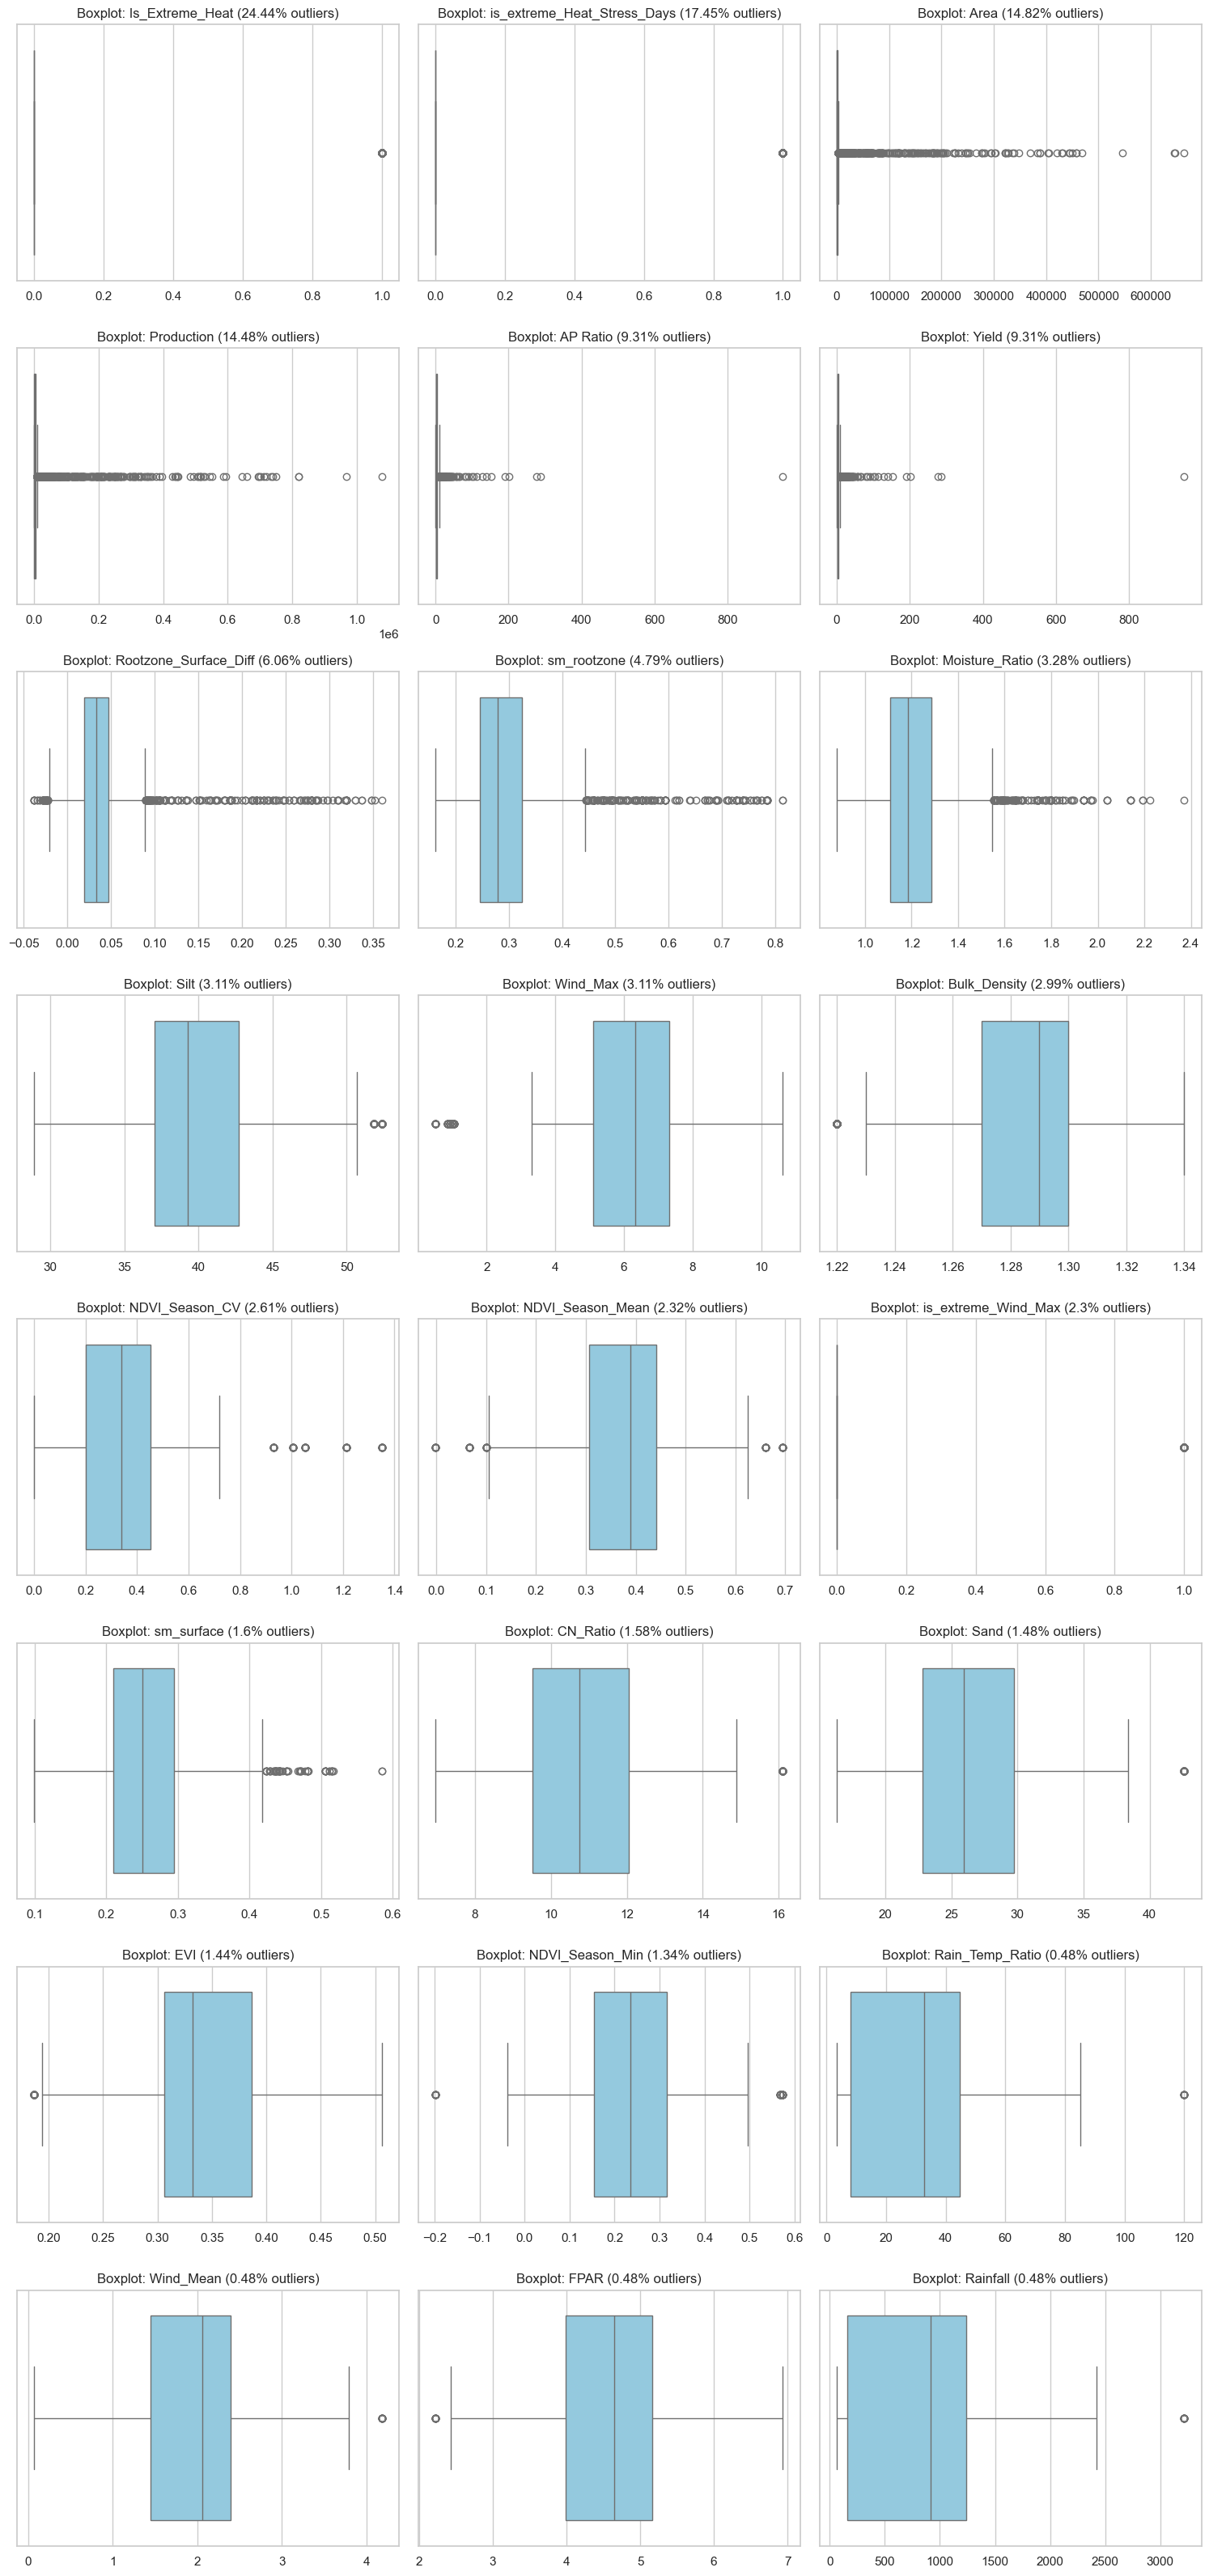

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cài đặt hiển thị cho đẹp
sns.set(style="whitegrid")
pd.set_option('display.max_rows', None) # Để hiển thị hết danh sách nếu dài

# 1. Lọc ra các cột dữ liệu số (Numerical columns) để phân tích
# Loại bỏ các cột ID hoặc Year nếu không cần thiết (tùy chọn)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Loại bỏ cột 'Year' nếu nó được xem là category, hoặc giữ lại tùy bạn. 
# Ở đây mình giữ lại hết để bạn kiểm tra.

print(f"Đang phân tích {len(numeric_cols)} cột dữ liệu số...")

# --- PHẦN 1: BẢNG THỐNG KÊ OUTLIER (DÙNG IQR) ---
outlier_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Định nghĩa biên dưới và biên trên
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm số lượng outlier
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (n_outliers / len(df)) * 100
    
    outlier_report.append({
        'Column': col,
        'Outliers_Count': n_outliers,
        'Outliers_Percentage (%)': round(pct_outliers, 2),
        'Lower_Bound': round(lower_bound, 2),
        'Upper_Bound': round(upper_bound, 2)
    })

# Tạo DataFrame báo cáo và sắp xếp theo tỷ lệ outlier giảm dần
outlier_df = pd.DataFrame(outlier_report)
outlier_df = outlier_df.sort_values(by='Outliers_Percentage (%)', ascending=False)

print("\n--- BẢNG TỔNG HỢP GIÁ TRỊ NGOẠI LAI (TOP CAO NHẤT) ---")
display(outlier_df.head(15)) # Hiển thị 15 cột có nhiều outlier nhất

# --- PHẦN 2: VẼ BOXPLOT (TRỰC QUAN HÓA) ---
# Chỉ vẽ các cột có outlier > 0 để đỡ rối mắt
cols_to_plot = outlier_df[outlier_df['Outliers_Count'] > 0]['Column'].tolist()

if cols_to_plot:
    n_cols = 3 # Số biểu đồ trên 1 hàng
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(15, 4 * n_rows))
    
    for i, col in enumerate(cols_to_plot):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot: {col} ({outlier_df.loc[outlier_df["Column"]==col, "Outliers_Percentage (%)"].values[0]}% outliers)')
        plt.xlabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print("Dữ liệu rất sạch! Không tìm thấy cột nào có outlier theo phương pháp IQR.")

In [80]:
# Hàm xử lý outlier cho từng nhóm
def remove_outliers_by_group(df, group_col, target_col):
    df_clean = df.copy()
    
    # Duyệt qua từng loại cây
    for crop in df[group_col].unique():
        # Lấy dữ liệu của riêng loại cây đó
        mask = df[group_col] == crop
        crop_data = df.loc[mask, target_col]
        
        # Tính IQR riêng cho loại cây này
        Q1 = crop_data.quantile(0.25)
        Q3 = crop_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Thiết lập biên (nới lỏng hơn chút, nhân 3 thay vì 1.5 để giữ lại các vụ mùa bội thu thực sự)
        lower = Q1 - 3 * IQR 
        upper = Q3 + 3 * IQR
        
        # Áp dụng Capping (gán về biên thay vì xóa)
        # Cách này giữ được dữ liệu nhưng làm nó bớt "ngông"
        df_clean.loc[mask & (df_clean[target_col] > upper), target_col] = upper
        df_clean.loc[mask & (df_clean[target_col] < lower), target_col] = lower
        
    return df_clean

# Áp dụng
df_final = remove_outliers_by_group(df, 'Crop Name', 'Yield')

# Kiểm tra lại sau khi xử lý
print(df_final.groupby('Crop Name')['Yield'].describe().sort_values(by='max', ascending=False).head())

               count       mean        std       min        25%        50%  \
Crop Name                                                                    
Jack Fruit      64.0  37.045403  35.999037  3.570000  13.315343  22.392099   
Green Papaya    64.0  14.437790  10.301153  0.809404   7.632386  12.967230   
Green Palmyra   62.0  10.429924   9.552421  0.290076   3.574332   6.827560   
Ripe Papaya     64.0  16.048289   8.505905  2.425000  10.357279  14.704872   
Green Coconut   64.0  12.859524   9.760431  0.645824   6.904532  10.276488   

                     75%         max  
Crop Name                             
Jack Fruit     38.088186  112.406717  
Green Papaya   18.598000   51.494843  
Green Palmyra  15.181626   50.003509  
Ripe Papaya    19.603846   47.343548  
Green Coconut  16.350500   44.688406  


In [81]:
df_final.to_csv('Agri_Data_Cleaned_Yield_Fixed.csv', index=False)

# Xử nhóm nhiệt độ 

In [82]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv('Agri_Data_Cleaned_Yield_Fixed.csv')

# 2. Tạo cột Temp_Range (Max - Min)
df['Temp_Range'] = df['Max Temp'] - df['Min Temp']

# 4. Kiểm tra kết quả (in ra 5 dòng đầu)
print(df[['Temp_Range']].head())
df['Drought_Index'] = df['Max Temp'] / df['Min Relative Humidity']

# 4. Xóa các cột theo yêu cầu:
# - Max Temp, Min Temp (Yêu cầu trước)
# - Avg Humidity, Max Relative Humidity (Yêu cầu hiện tại)
cols_to_drop = ['Max Temp', 'Min Temp', 'Avg Humidity', 'Max Relative Humidity']
df.drop(columns=cols_to_drop, inplace=True)

# 5. Kiểm tra kết quả
print(df[['Temp_Range', 'Drought_Index']].head())
print("Danh sách cột còn lại:", df.columns.tolist())

# 6. Lưu file kết quả mới
df.to_csv('Agri_Data_Processed_1.csv', index=False)


   Temp_Range
0        10.0
1        15.0
2        15.0
3        29.0
4        33.0
   Temp_Range  Drought_Index
0        10.0       0.500000
1        15.0       0.437500
2        15.0       0.437500
3        29.0       0.583333
4        33.0       0.542857
Danh sách cột còn lại: ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Min Relative Humidity', 'Year', 'EVI', 'LAI', 'FPAR', 'LST_Kelvin', 'Soil_Moisture_mm', 'NDVI_Season_Mean', 'NDVI_Season_Max', 'NDVI_Season_Min', 'NDVI_Season_Std', 'NDVI_Season_Range', 'NDVI_Season_CV', 'Avg_Salinity_Index', 'pH', 'Organic_Carbon', 'Nitrogen', 'Clay', 'Sand', 'Silt', 'Bulk_Density', 'CN_Ratio', 'pH_Suitability', 'Compaction_Risk', 'Dominant_Soil_Texture', 'sm_surface', 'sm_rootzone', 'Rootzone_Surface_Diff', 'Moisture_Ratio', 'Water_Availability_Cat', 'Rainfall', 'Heat_Stress_Days', 'Wind_Mean', 'Wind_Max', 'Wind_Min', 'Rain_Temp_Ratio', 'Extreme_Heat_Risk', 'Is_Extreme_Heat',

# xử nhóm vệ tinh  

In [83]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd # Đừng quên import pandas

df = pd.read_csv('Agri_Data_Processed_1.csv')

# 1. Chọn nhóm cột cần nén
sat_features = ['NDVI_Season_Mean', 'NDVI_Season_Max', 'NDVI_Season_Min', 
                'NDVI_Season_Range', 'EVI', 'LAI', 'FPAR']
# Lọc ra các cột thực sự có trong df
sat_features = [col for col in sat_features if col in df.columns]

# 2. Scale dữ liệu (Bắt buộc với PCA)
scaler_sat = StandardScaler()
X_sat = scaler_sat.fit_transform(df[sat_features])

# 3. Nén lại còn 2 cột
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sat)

# 4. Đưa 2 cột mới vào DataFrame
df['Satellite_Info_1'] = X_pca[:, 0]
df['Satellite_Info_2'] = X_pca[:, 1]

# 5. Xóa các cột cũ đi (để tránh đa cộng tuyến với cột mới)
df_final = df.drop(columns=sat_features)

print("Đã thay thế nhóm Vệ tinh bằng 2 biến tổng hợp PC1 và PC2!")
print(df_final[['Satellite_Info_1', 'Satellite_Info_2']].head())

# SỬA LỖI Ở ĐÂY: Dùng df_final để lưu thay vì df
df_final.to_csv('Agri_Data_Processed_2.csv', index=False)

Đã thay thế nhóm Vệ tinh bằng 2 biến tổng hợp PC1 và PC2!
   Satellite_Info_1  Satellite_Info_2
0          1.839618          2.111989
1         -2.153183          0.707592
2         -5.216839          0.697198
3         -5.216839          0.697198
4         -1.894090          1.387471


# xử nhóm đất

In [84]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Đọc file dữ liệu (Agri_Data_Processed_2.csv)
df = pd.read_csv('Agri_Data_Processed_2.csv')

# --- ĐOẠN CODE THÊM MỚI BẮT ĐẦU TỪ ĐÂY ---
# 1.5. Nén Nitrogen và Organic_Carbon thành Soil_Nutrient_Index
if 'Nitrogen' in df.columns and 'Organic_Carbon' in df.columns:
    # Scale dữ liệu trước khi PCA
    scaler = StandardScaler()
    X_soil = scaler.fit_transform(df[['Nitrogen', 'Organic_Carbon']])
    
    # Nén thành 1 cột
    pca = PCA(n_components=1)
    df['Soil_Nutrient_Index'] = pca.fit_transform(X_soil)
    print("Đã tạo thành công cột 'Soil_Nutrient_Index'.")
    
    # Xóa 2 cột cũ
    df.drop(columns=['Nitrogen', 'Organic_Carbon'], inplace=True)
    print("Đã xóa 2 cột 'Nitrogen' và 'Organic_Carbon'.")
else:
    print("Không tìm thấy cột 'Nitrogen' hoặc 'Organic_Carbon'.")
# --- ĐOẠN CODE THÊM MỚI KẾT THÚC ---

# 2. Xóa cột Silt (Code cũ giữ nguyên)
if 'Silt' in df.columns:
    df.drop(columns=['Silt'], inplace=True)
    print("Đã xóa cột 'Silt'.")
else:
    print("Không tìm thấy cột 'Silt'.")

# 3. Kiểm tra lại danh sách cột
print("Danh sách cột còn lại:", df.columns.tolist())

# 4. Lưu file kết quả mới
df.to_csv('Agri_Data_Processed_3.csv', index=False)

Đã tạo thành công cột 'Soil_Nutrient_Index'.
Đã xóa 2 cột 'Nitrogen' và 'Organic_Carbon'.
Đã xóa cột 'Silt'.
Danh sách cột còn lại: ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Min Relative Humidity', 'Year', 'LST_Kelvin', 'Soil_Moisture_mm', 'NDVI_Season_Std', 'NDVI_Season_CV', 'Avg_Salinity_Index', 'pH', 'Clay', 'Sand', 'Bulk_Density', 'CN_Ratio', 'pH_Suitability', 'Compaction_Risk', 'Dominant_Soil_Texture', 'sm_surface', 'sm_rootzone', 'Rootzone_Surface_Diff', 'Moisture_Ratio', 'Water_Availability_Cat', 'Rainfall', 'Heat_Stress_Days', 'Wind_Mean', 'Wind_Max', 'Wind_Min', 'Rain_Temp_Ratio', 'Extreme_Heat_Risk', 'Is_Extreme_Heat', 'is_extreme_Heat_Stress_Days', 'is_extreme_Wind_Max', 'Yield', 'Temp_Range', 'Drought_Index', 'Satellite_Info_1', 'Satellite_Info_2', 'Soil_Nutrient_Index']


# xử lý nước

In [85]:
import pandas as pd

# Đọc dữ liệu từ file CSV của bạn
df = pd.read_csv('Agri_Data_Processed_3.csv')

# 1. Tạo cột Heavy_Rain_Event TRƯỚC khi xóa Rainfall
# Điều kiện: 1 nếu Rainfall > 200, ngược lại là 0
df['Heavy_Rain_Event'] = (df['Rainfall'] > 200).astype(int)

# 2. Xóa các cột không cần thiết theo logic đã thống nhất
cols_to_drop = ['Rainfall', 'sm_surface', 'Moisture_Ratio','Is_Extreme_Heat', 'is_extreme_Heat_Stress_Days','Year']
df = df.drop(columns=cols_to_drop)

# --- Kiểm tra lại kết quả ---
# In ra 5 dòng đầu tiên của các cột quan trọng để xác nhận
print("Các cột hiện tại trong dataset:", df.columns.tolist())
print("\nXem trước dữ liệu các cột giữ lại và cột mới tạo:")
print(df[['Rain_Temp_Ratio', 'sm_rootzone', 'Heavy_Rain_Event']].head())

# 3. (Tùy chọn) Lưu lại thành một file CSV mới để dùng cho các bước tiếp theo
df.to_csv('Agri_Data_Processed_4.csv', index=False)

Các cột hiện tại trong dataset: ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Min Relative Humidity', 'LST_Kelvin', 'Soil_Moisture_mm', 'NDVI_Season_Std', 'NDVI_Season_CV', 'Avg_Salinity_Index', 'pH', 'Clay', 'Sand', 'Bulk_Density', 'CN_Ratio', 'pH_Suitability', 'Compaction_Risk', 'Dominant_Soil_Texture', 'sm_rootzone', 'Rootzone_Surface_Diff', 'Water_Availability_Cat', 'Heat_Stress_Days', 'Wind_Mean', 'Wind_Max', 'Wind_Min', 'Rain_Temp_Ratio', 'Extreme_Heat_Risk', 'is_extreme_Wind_Max', 'Yield', 'Temp_Range', 'Drought_Index', 'Satellite_Info_1', 'Satellite_Info_2', 'Soil_Nutrient_Index', 'Heavy_Rain_Event']

Xem trước dữ liệu các cột giữ lại và cột mới tạo:
   Rain_Temp_Ratio  sm_rootzone  Heavy_Rain_Event
0            50.58       0.3725                 1
1            31.20       0.3207                 1
2            75.86       0.4462                 1
3            75.86       0.2815                 1
4          

In [86]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Đọc dữ liệu hiện tại
df = pd.read_csv('Agri_Data_Processed_4.csv')

# Kiểm tra xem 2 cột có tồn tại không
if 'LST_Kelvin' in df.columns and 'Heavy_Rain_Event' in df.columns:
    
    # 2. Xây dựng mô hình hồi quy phụ (Dự đoán LST từ Heavy_Rain)
    # Cần reshape lại cho đúng định dạng của sklearn
    X_temp = df[['Heavy_Rain_Event']]
    y_temp = df['LST_Kelvin']
    
    model_res = LinearRegression()
    model_res.fit(X_temp, y_temp)
    
    # 3. Tính toán phần dư (Residuals) - Đây chính là LST_Adjusted
    # Công thức: Thực tế - Dự đoán
    LST_predicted = model_res.predict(X_temp)
    df['LST_Adjusted'] = y_temp - LST_predicted
    
    # 4. Xóa cột LST_Kelvin gốc
    df = df.drop(columns=['LST_Kelvin'])
    
    print("Đã tạo thành công 'LST_Adjusted' và xóa 'LST_Kelvin' gốc!")
    
    # (Tùy chọn) Kiểm tra lại độ tương quan để chứng minh nó bằng 0
    corr_check = df['LST_Adjusted'].corr(df['Heavy_Rain_Event'])
    print(f"Độ tương quan mới giữa LST_Adjusted và Heavy_Rain_Event: {corr_check:.5f}")

# 5. Xóa các cột gây đa cộng tuyến khác (Nhóm vệ tinh, gió, diện tích, hạn hán...)
cols_to_remove = ['Production', 'Area', 'Wind_Mean', 'NDVI_Season_Std', 
                  'NDVI_Season_CV', 'Avg_Salinity_Index', 'Drought_Index']

cols_to_remove = [col for col in cols_to_remove if col in df.columns]
df_final = df.drop(columns=cols_to_remove)

# 6. Lưu file hoàn hảo
df_final.to_csv('Agri_Data_Processed_5.csv', index=False)
print("\nĐã dọn dẹp toàn bộ dữ liệu. File 'Agri_Data_Final_Cleaned.csv' sẵn sàng cho Linear Regression!")

Đã tạo thành công 'LST_Adjusted' và xóa 'LST_Kelvin' gốc!
Độ tương quan mới giữa LST_Adjusted và Heavy_Rain_Event: 0.00000

Đã dọn dẹp toàn bộ dữ liệu. File 'Agri_Data_Final_Cleaned.csv' sẵn sàng cho Linear Regression!


# 

In [87]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Đọc dữ liệu từ file cuối cùng
df = pd.read_csv('Agri_Data_Processed_5.csv')

# Kiểm tra các cột cần thiết
cols_needed = ['Rain_Temp_Ratio', 'Heavy_Rain_Event', 'Satellite_Info_2']
if all(col in df.columns for col in cols_needed):
    
    # 2. Xây dựng mô hình tách nhiễu (Khử tương quan với cả 2 biến cùng lúc)
    X_noise = df[['Heavy_Rain_Event', 'Satellite_Info_2']]
    y_target = df['Rain_Temp_Ratio']
    
    model_res = LinearRegression()
    model_res.fit(X_noise, y_target)
    
    # 3. Tính toán phần dư -> Tạo biến Adjusted mới
    predicted_ratio = model_res.predict(X_noise)
    df['Rain_Temp_Ratio_Adjusted'] = y_target - predicted_ratio
    
    # 4. Xóa cột gốc
    df = df.drop(columns=['Rain_Temp_Ratio'])
    
    print("Đã tạo thành công 'Rain_Temp_Ratio_Adjusted'!")
    
    # --- Kiểm tra lại để chứng minh độ tương quan đã bị triệt tiêu ---
    corr_rain = df['Rain_Temp_Ratio_Adjusted'].corr(df['Heavy_Rain_Event'])
    corr_sat = df['Rain_Temp_Ratio_Adjusted'].corr(df['Satellite_Info_2'])
    
    print(f"Độ tương quan với Heavy_Rain_Event: {corr_rain:.5f} (Gần bằng 0)")
    print(f"Độ tương quan với Satellite_Info_2: {corr_sat:.5f} (Gần bằng 0)")
else:
    print("Không tìm thấy đủ các cột cần thiết trong file!")

# 5. Lưu lại file dữ liệu phiên bản tối ưu nhất
df.to_csv('Agri_Data_Processed_6.csv', index=False)
print("\nĐã lưu file hoàn thiện: 'Agri_Data_Processed_6.csv'")

Đã tạo thành công 'Rain_Temp_Ratio_Adjusted'!
Độ tương quan với Heavy_Rain_Event: 0.00000 (Gần bằng 0)
Độ tương quan với Satellite_Info_2: 0.00000 (Gần bằng 0)

Đã lưu file hoàn thiện: 'Agri_Data_Processed_6.csv'


# check độ tương quan

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc dữ liệu từ 2 file CSV
df_cleaned = pd.read_csv('Agri_Data_Cleaned_Yield_Fixed.csv')
df_processed = pd.read_csv('Agri_Data_Processed_6.csv')

# 2. Lọc ra các cột chứa dữ liệu số (loại bỏ các cột text để không bị lỗi)
numeric_cleaned = df_cleaned.select_dtypes(include=[np.number])
numeric_processed = df_processed.select_dtypes(include=[np.number])

# 3. Tính toán ma trận tương quan (Pearson)
corr_cleaned = numeric_cleaned.corr()
corr_processed = numeric_processed.corr()

# 4. Hàm vẽ biểu đồ Nhiệt (Heatmap)
def plot_correlation(corr_matrix, title, filename):
    plt.figure(figsize=(24, 20)) # Kích thước lớn vì có nhiều biến
    
    # Tạo mặt nạ che nửa tam giác trên (do ma trận đối xứng nên nửa trên và dưới giống nhau)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Tạo thang màu (Đỏ = tương quan dương, Xanh = tương quan âm)
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    # Vẽ heatmap
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    
    plt.title(title, fontsize=24)
    plt.xticks(rotation=90, fontsize=12) # Xoay tên cột để dễ đọc
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    # Lưu biểu đồ thành file ảnh thay vì hiện ra màn hình
    plt.savefig(filename, dpi=300)
    plt.close() # Đóng biểu đồ để giải phóng bộ nhớ

# 5. Gọi hàm để vẽ và lưu 2 biểu đồ
plot_correlation(corr_cleaned, 'Ma Trận Tương Quan - Cleaned Data', 'correlation_cleaned.png')
plot_correlation(corr_processed, 'Ma Trận Tương Quan - Processed Data 4', 'correlation_processed.png')

print("Đã vẽ xong và lưu thành 2 file ảnh: correlation_cleaned.png và correlation_processed.png!")

Đã vẽ xong và lưu thành 2 file ảnh: correlation_cleaned.png và correlation_processed.png!
